# 퍼셉트론

In [2]:
import numpy as np

In [3]:
# 입력값 x1 = 1, x2 = 0
x = np.array([1, 0])
# 가중치 w
w = np.array([0.6, 0.4])
# 편향
b = -0.5

# z 값 = 가중합 + 편향
z = np.dot(w, x) + b

In [4]:
# 시그모이드 함수
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


In [ ]:
# 시그모이드(z)가 0.5보다 큰 경우 1
sigmoid(z)

np.float64(0.5249791874789399)

C:\Users\RookieFit\AppData\Local\Temp\ipykernel_6332\739744295.py:13: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\RookieFit\AppData\Local\Temp\ipykernel_6332\739744295.py:13: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\RookieFit\AppData\Local\Temp\ipykernel_6332\739744295.py:13: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\RookieFit\p1-data\c3-deep-learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\RookieFit\p1-data\c3-deep-learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\RookieFit\

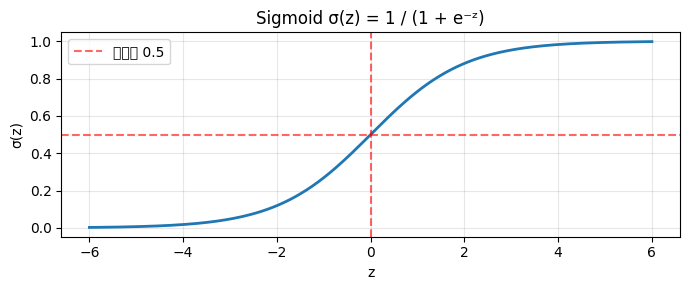

In [6]:
import matplotlib.pyplot as plt

z_range = np.linspace(-6, 6, 200)
plt.figure(figsize=(7, 3))
plt.plot(z_range, sigmoid(z_range), lw=2)
plt.axhline(0.5, color='r', linestyle='--', alpha=0.6, label='임계값 0.5')
plt.axvline(0,   color='r', linestyle='--', alpha=0.6)
plt.title('Sigmoid σ(z) = 1 / (1 + e⁻ᶻ)')
plt.xlabel('z')
plt.ylabel('σ(z)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# 퍼셉트론 함수
def perceptron(x, w, b, threshold=0.5):
    z = np.dot(w, x) + b
    a = sigmoid(z)
    predict = int(a > threshold) # 임계치보다 크면 1, 작으면 0
    return predict, a, z


In [ ]:
pred, a, z = perceptron(x, w, b)


1

# 진리표

In [10]:
# AND 게이트
w_and = np.array([1.0, 1.0])
b_and = -1.5

inputs  = [(0,0), (0,1), (1,0), (1,1)]
targets = [  0,     0,     0,     1  ]

print("AND 게이트  (w=[1,1], b=-1.5)")
print(f"{'x1':>3} {'x2':>3} │ {'z':>6}  {'σ(z)':>6}  {'예측':>4}  {'정답':>4}  {'✓/✗':>4}")
print("─" * 45)
for (x1, x2), t in zip(inputs, targets):
    pred, a, z = perceptron(np.array([x1, x2]), w_and, b_and)
    ok = "✓" if pred == t else "✗"
    print(f"  {x1}   {x2}  │ {z:>6.1f}  {a:>6.3f}  {pred:>4}  {t:>4}  {ok:>4}")

AND 게이트  (w=[1,1], b=-1.5)
 x1  x2 │      z    σ(z)    예측    정답   ✓/✗
─────────────────────────────────────────────
  0   0  │   -1.5   0.182     0     0     ✓
  0   1  │   -0.5   0.378     0     0     ✓
  1   0  │   -0.5   0.378     0     0     ✓
  1   1  │    0.5   0.622     1     1     ✓


In [12]:
# OR 게이트
w_or = np.array([1.0, 1.0])
b_or = -0.5

inputs  = [(0,0), (0,1), (1,0), (1,1)]
targets = [  0,     1,     1,     1  ]

print("OR 게이트  (w=[1,1], b=-0.5)")
print(f"{'x1':>3} {'x2':>3} │ {'z':>6}  {'σ(z)':>6}  {'예측':>4}  {'정답':>4}  {'✓/✗':>4}")
print("─" * 45)
for (x1, x2), t in zip(inputs, targets):
    pred, a, z = perceptron(np.array([x1, x2]), w_or, b_or)
    ok = "✓" if pred == t else "✗"
    print(f"  {x1}   {x2}  │ {z:>6.1f}  {a:>6.3f}  {pred:>4}  {t:>4}  {ok:>4}")

OR 게이트  (w=[1,1], b=-0.5)
 x1  x2 │      z    σ(z)    예측    정답   ✓/✗
─────────────────────────────────────────────
  0   0  │   -0.5   0.378     0     0     ✓
  0   1  │    0.5   0.622     1     1     ✓
  1   0  │    0.5   0.622     1     1     ✓
  1   1  │    1.5   0.818     1     1     ✓


In [13]:
# 가중치와 편향 조합이 학습된 지식이다

In [ ]:
# b 값에 따른 활성화 기준 변화
print("편향에 따른 σ(z) at x=[1,1]:")
for b_val in [-2.0, -1.5, -1.0, -0.5, 0.0, 0.5]:
    z = 1+1+b_val   # w=[1,1], x=[1,1] → z = 2+b
    a = sigmoid(z)
    print(f"  b={b_val:+.1f} → z={z:+.1f} → σ={a:.3f}  {'← 활성화' if a>=0.5 else ''}")

# b가 작을수록 더 까다로운 조건에 활성화되고,
# b가 클수록 쉽게 활성화가 된다.

편향에 따른 σ(z) at x=[1,1]:
  b=-2.0 → z=+0.0 → σ=0.500  ← 활성화
  b=-1.5 → z=+0.5 → σ=0.622  ← 활성화
  b=-1.0 → z=+1.0 → σ=0.731  ← 활성화
  b=-0.5 → z=+1.5 → σ=0.818  ← 활성화
  b=+0.0 → z=+2.0 → σ=0.881  ← 활성화
  b=+0.5 → z=+2.5 → σ=0.924  ← 활성화


In [15]:
# XOR 한계
targets_xor = [0, 1, 1, 0]

def test_gate(w, b, label):
    correct = 0
    for (x1, x2), t in zip(inputs, targets_xor):
        pred, _, _ = perceptron(np.array([x1, x2]), w, b)
        correct += (pred == t)
    print(f"  {label}: {correct}/4 correct  {'✓ 성공!' if correct==4 else '✗'}")

print("XOR 게이트 — 다양한 w, b 시도:")
test_gate(np.array([ 1.0,  1.0]),  0.0, "w=[ 1, 1], b= 0.0")
test_gate(np.array([ 1.0, -1.0]),  0.0, "w=[ 1,-1], b= 0.0")
test_gate(np.array([ 2.0, -1.0]), -0.5, "w=[ 2,-1], b=-0.5")
test_gate(np.array([-1.0,  2.0]),  0.0, "w=[-1, 2], b= 0.0")
print()

XOR 게이트 — 다양한 w, b 시도:
  w=[ 1, 1], b= 0.0: 3/4 correct  ✗
  w=[ 1,-1], b= 0.0: 3/4 correct  ✗
  w=[ 2,-1], b=-0.5: 2/4 correct  ✗
  w=[-1, 2], b= 0.0: 2/4 correct  ✗



C:\Users\RookieFit\AppData\Local\Temp\ipykernel_6332\2209040321.py:32: UserWarning: Glyph 48744 (\N{HANGUL SYLLABLE BBAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\RookieFit\AppData\Local\Temp\ipykernel_6332\2209040321.py:32: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\RookieFit\AppData\Local\Temp\ipykernel_6332\2209040321.py:32: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\RookieFit\AppData\Local\Temp\ipykernel_6332\2209040321.py:32: UserWarning: Glyph 46993 (\N{HANGUL SYLLABLE RANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\RookieFit\AppData\Local\Temp\ipykernel_6332\2209040321.py:32: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\RookieFit\AppData\Local\Temp\ipykernel_6332\2209040321.py:32: UserWarning: Glyph 51221 (\N{HANGUL SYLL

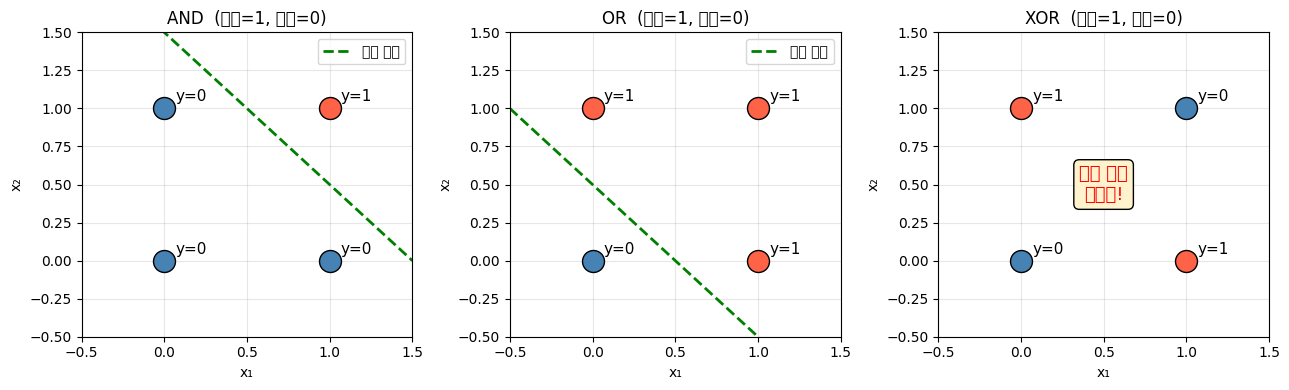

In [16]:
import matplotlib.pyplot as plt

points = [(0,0), (0,1), (1,0), (1,1)]
and_labels = [0, 0, 0, 1]
or_labels  = [0, 1, 1, 1]
xor_labels = [0, 1, 1, 0]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, labels, title in zip(axes,
        [and_labels, or_labels, xor_labels], ['AND', 'OR', 'XOR']):
    for (x1, x2), y in zip(points, labels):
        ax.scatter(x1, x2, c='tomato' if y==1 else 'steelblue',
                   s=250, zorder=3, edgecolors='k')
        ax.annotate(f'y={y}', (x1, x2),
                    textcoords='offset points', xytext=(8, 5), fontsize=11)
    ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
    ax.set_title(f'{title}  (빨강=1, 파랑=0)', fontsize=12)
    ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
    ax.grid(True, alpha=0.3)
    # AND, OR는 분리선 그리기
    x_line = np.linspace(-0.5, 1.5, 100)
    if title == 'AND':
        ax.plot(x_line, 1.5 - x_line, 'g--', lw=2, label='결정 경계')
        ax.legend(fontsize=10)
    elif title == 'OR':
        ax.plot(x_line, 0.5 - x_line, 'g--', lw=2, label='결정 경계')
        ax.legend(fontsize=10)
    else:
        ax.text(0.5, 0.5, '직선 분리\n불가능!', ha='center', va='center',
                fontsize=13, color='red',
                bbox=dict(boxstyle='round', facecolor='#fff3cd'))
plt.tight_layout()
plt.show()

In [17]:
inputs = [
    np.array([0, 0]),
    np.array([0, 1]),
    np.array([1, 0]),
    np.array([1, 1]),
]

X = np.array(inputs)
y_xor = np.array([0, 1, 1, 0])


def AND(x):
    w = np.array([1.0, 1.0])
    b = -1.5
    pred, a, z = perceptron(x, w, b)
    return pred, a, z


def OR(x):
    w = np.array([1.0, 1.0])
    b = -0.5
    pred, a, z = perceptron(x, w, b)
    return pred, a, z


def NAND(x):
    w = np.array([-1.0, -1.0])
    b = 1.5
    pred, a, z = perceptron(x, w, b)
    return pred, a, z


def XOR(x):
    # 은닉층 1번 뉴런: OR
    or_pred, or_a, or_z = OR(x)

    # 은닉층 2번 뉴런: NAND
    nand_pred, nand_a, nand_z = NAND(x)

    # 은닉층 출력
    hidden = np.array([or_pred, nand_pred])

    # 출력층 뉴런: AND
    xor_pred, xor_a, xor_z = AND(hidden)

    return {
        "x": x,
        "or_pred": or_pred,
        "or_a": or_a,
        "or_z": or_z,
        "nand_pred": nand_pred,
        "nand_a": nand_a,
        "nand_z": nand_z,
        "hidden": hidden,
        "xor_pred": xor_pred,
        "xor_a": xor_a,
        "xor_z": xor_z,
    }

In [18]:

print("XOR by Multi-Layer Perceptron")
print(f"{'x1':>3} {'x2':>3} | {'OR':>3} {'NAND':>5} | {'XOR':>3}")
print("-" * 32)

for x in inputs:
    result = XOR(x)

    print(
        f"{x[0]:>3} {x[1]:>3} | "
        f"{result['or_pred']:>3} {result['nand_pred']:>5} | "
        f"{result['xor_pred']:>3}"
    )


XOR by Multi-Layer Perceptron
 x1  x2 |  OR  NAND | XOR
--------------------------------
  0   0 |   0     1 |   0
  0   1 |   1     1 |   1
  1   0 |   1     1 |   1
  1   1 |   1     0 |   0



원본 입력 X
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

은닉층 출력 H = [OR, NAND]
[[0 1]
 [1 1]
 [1 1]
 [1 0]]

XOR 정답
[0 1 1 0]


C:\Users\RookieFit\AppData\Local\Temp\ipykernel_6332\2556381844.py:80: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\RookieFit\AppData\Local\Temp\ipykernel_6332\2556381844.py:80: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\RookieFit\AppData\Local\Temp\ipykernel_6332\2556381844.py:80: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\RookieFit\AppData\Local\Temp\ipykernel_6332\2556381844.py:80: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\RookieFit\AppData\Local\Temp\ipykernel_6332\2556381844.py:80: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\RookieFit\AppData\Local\Temp\ipykernel_6332\2556381844.py:80: UserWarning: Glyph 44036 (\N{HANGUL SYLLA

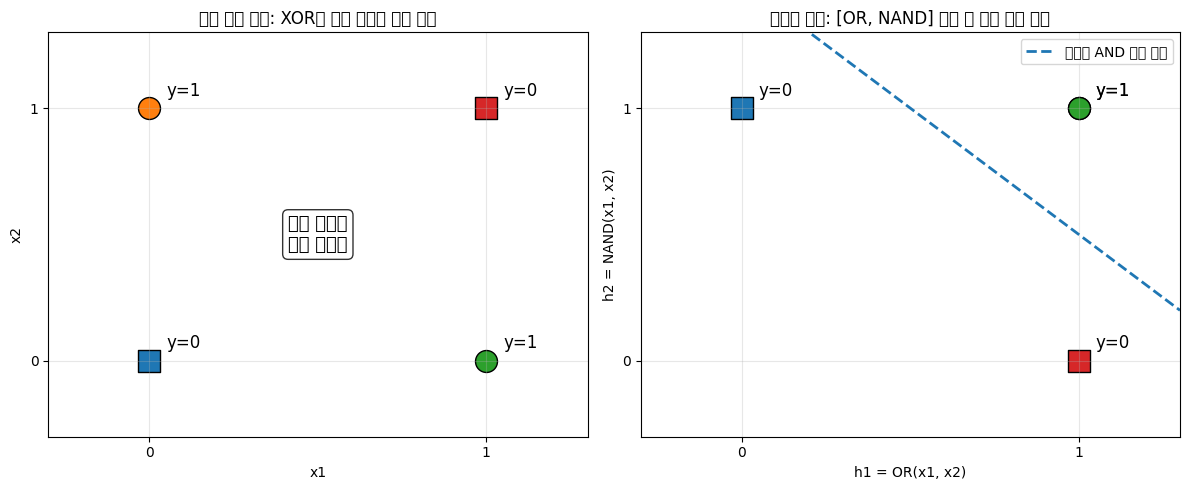

In [21]:
# ------------------------------------------------------------
# 시각화 : 원본 입력 공간 vs 은닉층 공간
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -----------------------------
# 1. 원본 입력 공간의 XOR
# -----------------------------
ax = axes[0]

H = []

for x in X:
    result = XOR(x)
    H.append(result["hidden"])

H = np.array(H)

print("\n원본 입력 X")
print(X)

print("\n은닉층 출력 H = [OR, NAND]")
print(H)

print("\nXOR 정답")
print(y_xor)

for point, label in zip(X, y_xor):
    marker = "o" if label == 1 else "s"
    ax.scatter(point[0], point[1], s=250, marker=marker, edgecolor="black")
    ax.text(point[0] + 0.05, point[1] + 0.05, f"y={label}", fontsize=12)

ax.set_title("원본 입력 공간: XOR는 직선 하나로 분리 불가")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_xlim(-0.3, 1.3)
ax.set_ylim(-0.3, 1.3)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.grid(True, alpha=0.3)

ax.text(
    0.5, 0.5,
    "직선 하나로\n분리 불가능",
    ha="center",
    va="center",
    fontsize=13,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

# -----------------------------
# 2. 은닉층 공간의 XOR
# -----------------------------
ax = axes[1]

for point, label in zip(H, y_xor):
    marker = "o" if label == 1 else "s"
    ax.scatter(point[0], point[1], s=250, marker=marker, edgecolor="black")
    ax.text(point[0] + 0.05, point[1] + 0.05, f"y={label}", fontsize=12)

# 출력층 AND 결정 경계:
# h1 + h2 - 1.5 = 0
# h2 = 1.5 - h1
h1_line = np.linspace(-0.3, 1.3, 100)
h2_line = 1.5 - h1_line

ax.plot(h1_line, h2_line, linestyle="--", linewidth=2, label="출력층 AND 결정 경계")

ax.set_title("은닉층 공간: [OR, NAND] 변환 후 선형 분리 가능")
ax.set_xlabel("h1 = OR(x1, x2)")
ax.set_ylabel("h2 = NAND(x1, x2)")
ax.set_xlim(-0.3, 1.3)
ax.set_ylim(-0.3, 1.3)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

